In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('cleaned_FMCG_SALES.csv')

df.shape

(50000, 18)

In [3]:
df.head(5)

,Order_ID,Company_Name,Order_Date,State,City,City_Tier,Store_Type,Product_Category,Product_Name,Quantity_Sold,Unit_Price_INR,Payment_Method,GST_Rate_Pct,Discount_Applied_Pct,Delivery_Days,Gross_Amount,Discount_Amount,Net_Sales_INR
0,IND-2024-100000,Reliance Jio Infocomm,26/01/2024,Telangana,Hyderabad,Tier 1,Supermarket,Packaged Food,Parle-G Gold Biscuits 1kg,22,140.0,UPI,5,5,2,3080.0,154.0,2926.0
1,IND-2024-100001,Tata Consultancy Services,28/07/2025,Bihar,Patna,Tier 3,Quick-Commerce Hub,Household Supplies,Vim Dishwash Liquid Gel 750ml,9,155.0,Cash / COD,18,10,3,1395.0,139.5,1255.5
2,IND-2024-100002,Mahindra & Mahindra,14/04/2024,Uttar Pradesh,Lucknow,Tier 2,Kirana Store,Dairy & Staples,Aashirvaad Shuddh Atta 10kg,20,440.0,UPI,0,15,1,8800.0,1320.0,7480.0
3,IND-2024-100003,Flipkart India,01/05/2025,Karnataka,Bengaluru,Tier 1,Kirana Store,Dairy & Staples,Amul Pasteurized Butter 500g,3,275.0,Credit Card,0,10,2,825.0,82.5,742.5
4,IND-2024-100004,Wipro Enterprise,17/11/2025,Karnataka,Bengaluru,Tier 1,Supermarket,Beverages,Nescafe Classic Instant Coffee 100g,6,290.0,Debit Card,18,10,7,1740.0,174.0,1566.0


In [4]:
df.columns

Index(['Order_ID', 'Company_Name', 'Order_Date', 'State', 'City', 'City_Tier',
       'Store_Type', 'Product_Category', 'Product_Name', 'Quantity_Sold',
       'Unit_Price_INR', 'Payment_Method', 'GST_Rate_Pct',
       'Discount_Applied_Pct', 'Delivery_Days', 'Gross_Amount',
       'Discount_Amount', 'Net_Sales_INR'],
      dtype='str')

In [5]:
df.isnull().sum()

Order_ID                0
Company_Name            0
Order_Date              0
State                   0
City                    0
City_Tier               0
Store_Type              0
Product_Category        0
Product_Name            0
Quantity_Sold           0
Unit_Price_INR          0
Payment_Method          0
GST_Rate_Pct            0
Discount_Applied_Pct    0
Delivery_Days           0
Gross_Amount            0
Discount_Amount         0
Net_Sales_INR           0
dtype: int64

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Order_ID              50000 non-null  str    
 1   Company_Name          50000 non-null  str    
 2   Order_Date            50000 non-null  str    
 3   State                 50000 non-null  str    
 4   City                  50000 non-null  str    
 5   City_Tier             50000 non-null  str    
 6   Store_Type            50000 non-null  str    
 7   Product_Category      50000 non-null  str    
 8   Product_Name          50000 non-null  str    
 9   Quantity_Sold         50000 non-null  int64  
 10  Unit_Price_INR        50000 non-null  float64
 11  Payment_Method        50000 non-null  str    
 12  GST_Rate_Pct          50000 non-null  int64  
 13  Discount_Applied_Pct  50000 non-null  int64  
 14  Delivery_Days         50000 non-null  int64  
 15  Gross_Amount          50000 no

In [7]:
df.describe()

,Quantity_Sold,Unit_Price_INR,GST_Rate_Pct,Discount_Applied_Pct,Delivery_Days,Gross_Amount,Discount_Amount,Net_Sales_INR
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,13.047240,282.357100,10.529820,12.525400,4.022100,3681.078800,463.747575,3217.331225
std,7.214101,121.877806,7.706552,8.526301,2.019875,2720.926127,523.720456,2403.872841
min,1.000000,120.000000,0.000000,0.000000,1.000000,120.000000,0.000000,90.000000
25%,7.000000,155.000000,5.000000,5.000000,2.000000,1550.000000,77.000000,1344.000000
50%,13.000000,275.000000,18.000000,15.000000,4.000000,2970.000000,290.000000,2610.000000
75%,19.000000,380.000000,18.000000,20.000000,6.000000,5280.000000,660.000000,4640.000000
max,25.000000,495.000000,18.000000,25.000000,7.000000,12375.000000,3093.750000,12375.000000


In [8]:
print("Total Orders:", df["Order_ID"].nunique())

print("Total Sales:", df["Net_Sales_INR"].sum())

print("Average Order Value:", df["Net_Sales_INR"].mean())

print("Total Quantity Sold:", df["Quantity_Sold"].sum())

Total Orders: 50000
Total Sales: 160866561.25
Average Order Value: 3217.331225
Total Quantity Sold: 652362


In [9]:
category_sales = df.groupby("Product_Category")["Net_Sales_INR"].sum()

print(category_sales)

Product_Category
Beverages             34257147.00
Dairy & Staples       40917027.25
Household Supplies    30561891.25
Packaged Food         14808899.00
Personal Care         40321596.75
Name: Net_Sales_INR, dtype: float64


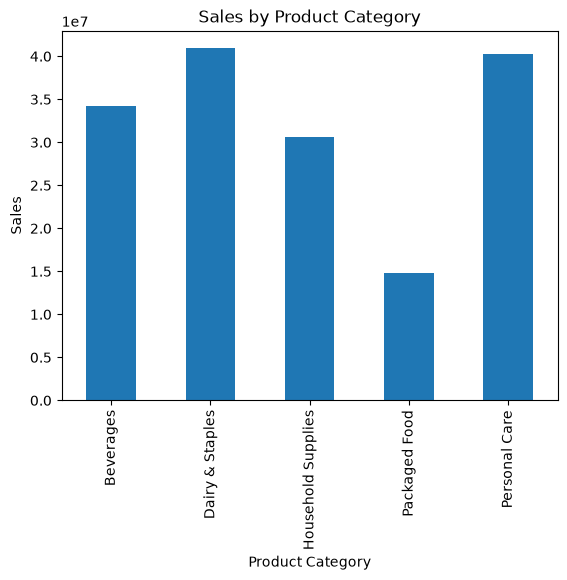

In [10]:
category_sales.plot(kind="bar")

plt.title("Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Sales")

plt.show()

In [11]:
state_sales = df.groupby("State")["Net_Sales_INR"].sum()

print(state_sales.sort_values(ascending=False).head(10))

State
Gujarat           16366074.50
Tamil Nadu        16360246.00
Bihar             16322027.75
Maharashtra       16262181.00
Rajasthan         16207413.25
Uttar Pradesh     16099711.00
Madhya Pradesh    15984763.75
Telangana         15898181.50
Delhi NCR         15889987.00
Karnataka         15475975.50
Name: Net_Sales_INR, dtype: float64


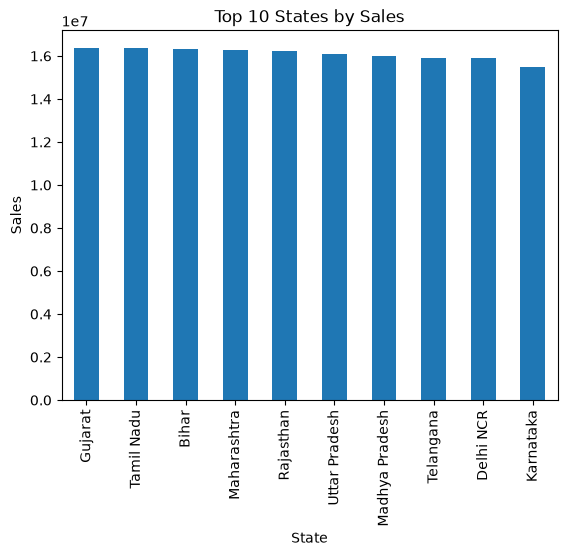

In [12]:
state_sales.sort_values(ascending=False).head(10).plot(kind="bar")

plt.title("Top 10 States by Sales")
plt.xlabel("State")
plt.ylabel("Sales")

plt.show()

In [13]:
store_sales = df.groupby("Store_Type")["Net_Sales_INR"].sum()

print(store_sales)

Store_Type
Hypermarket           39890839.00
Kirana Store          41018503.50
Quick-Commerce Hub    40106702.50
Supermarket           39850516.25
Name: Net_Sales_INR, dtype: float64


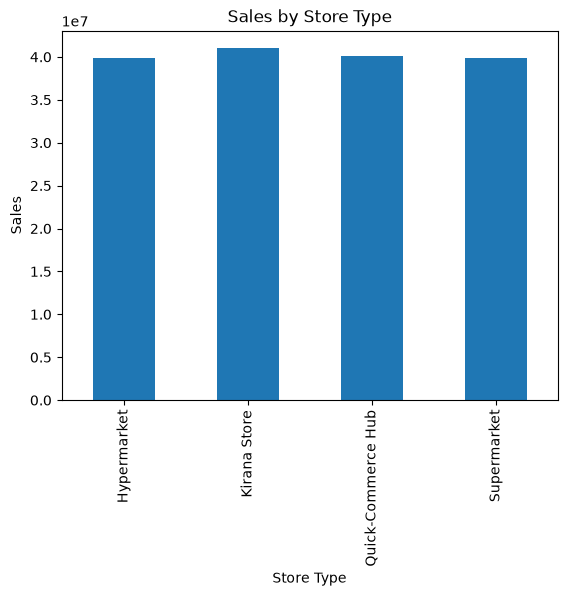

In [14]:
store_sales.plot(kind="bar")

plt.title("Sales by Store Type")
plt.xlabel("Store Type")
plt.ylabel("Sales")

plt.show()

In [15]:
tier_sales = df.groupby("City_Tier")["Net_Sales_INR"].sum()

print(tier_sales)

City_Tier
Tier 1    79886571.00
Tier 2    64657962.50
Tier 3    16322027.75
Name: Net_Sales_INR, dtype: float64


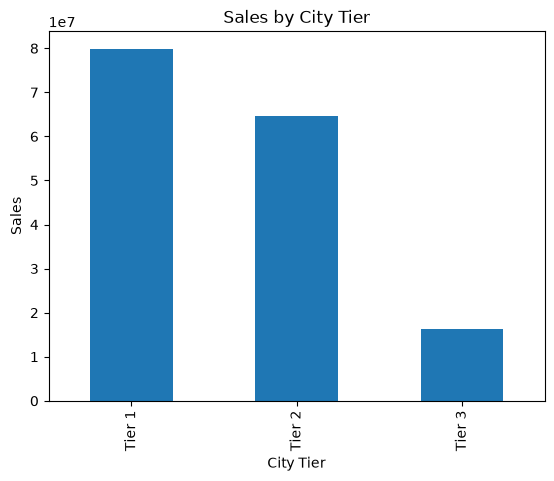

In [16]:
tier_sales.plot(kind="bar")

plt.title("Sales by City Tier")
plt.xlabel("City Tier")
plt.ylabel("Sales")

plt.show()

In [17]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"], dayfirst=True)

In [18]:
monthly_sales = df.groupby(
    df["Order_Date"].dt.to_period("M")
)["Net_Sales_INR"].sum()

print(monthly_sales)

Order_Date
2024-01    7085770.25
2024-02    6436823.00
2024-03    7208210.50
2024-04    7192569.00
2024-05    6833605.25
2024-06    7041713.50
2024-07    6951215.50
2024-08    6657971.00
2024-09    6680088.25
2024-10    7241045.50
2024-11    6932408.50
2024-12    6689151.25
2025-01    6794452.75
2025-02    6377143.75
2025-03    6924687.00
2025-04    6699649.75
2025-05    6614571.25
2025-06    6607392.25
2025-07    6800018.00
2025-08    6987622.00
2025-09    6345700.25
2025-10    6691621.75
2025-11    6632382.50
2025-12    4440748.50
Freq: M, Name: Net_Sales_INR, dtype: float64


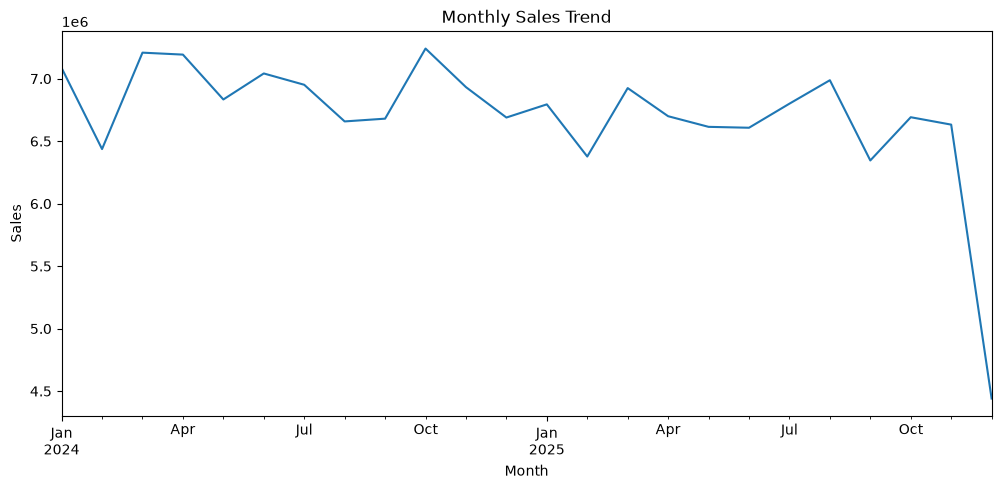

In [19]:
monthly_sales.plot(kind="line", figsize=(12,5))

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()

In [20]:
df[["Order_ID", "Product_Category", "Quantity_Sold", "Net_Sales_INR"]] \
.sort_values("Net_Sales_INR", ascending=False) \
.head(10)

,Order_ID,Product_Category,Quantity_Sold,Net_Sales_INR
23837,IND-2024-123837,Personal Care,25,12375.0
29556,IND-2024-129556,Personal Care,25,12375.0
48344,IND-2024-148344,Personal Care,25,12375.0
36936,IND-2024-136936,Personal Care,25,12375.0
16942,IND-2024-116942,Personal Care,25,12375.0
49688,IND-2024-149688,Personal Care,25,12375.0
34237,IND-2024-134237,Personal Care,25,12375.0
10586,IND-2024-110586,Personal Care,25,12375.0
35355,IND-2024-135355,Personal Care,25,12375.0
43914,IND-2024-143914,Personal Care,25,12375.0


In [21]:
df["Discount_Applied_Pct"].corr(df["Net_Sales_INR"])

np.float64(-0.11927455541249668)

# Exploratory Data Analysis — Summary

## Key Findings

1. The dataset contains 50,000 orders and approximately ₹160.87 million in net sales.

2. Dairy & Staples is one of the largest contributors to total sales.

3. Sales vary across states, with some states contributing significantly more than others.

4. Kirana Stores generate the highest sales among the store types in the dataset.

5. Tier 1 cities generate the highest sales compared with Tier 2 and Tier 3 cities.

6. Monthly sales show variation throughout the period, with some months performing better than others.

7. Some orders have unusually high sales values and should be investigated further.

8. The relationship between discount percentage and net sales is weakly negative in this dataset.


# Conclusion

The exploratory analysis helped identify the main sales patterns in the FMCG dataset.

The analysis shows differences in sales across product categories, states, store types and city tiers. Monthly sales also vary over time, while some orders have unusually high sales values.

These findings can help the business understand its sales performance and identify areas that may require further investigation.

The results from this analysis will be used for the next stage of the project, including business reporting and dashboard development.
